# Clustering Exploration

This notebook explores whether slab properties and Extended Column Test (ECT) results form useful clusters in the SnowPylot dataset. The workflow is intentionally linear: load CAAML pits, build slabs from the layer of concern, derive numerical slab and ECT features, scale complete cases, fit PCA, then cluster the first two principal components.

The cluster labels are exploratory. The `near_avalanche` marker is held out as a contextual verification label, not as an input feature.


## Setup

All imports, paths, model settings, and feature choices live here so the rest of the notebook reads like an analysis narrative. `bending_stiffness_D11_N_mm` is calculated for coverage review, but it is not used in PCA or clustering because too few slabs have complete D11 inputs.


In [27]:
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR
    NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"

SNOWPYT_MECHPARAMS_SRC = PROJECT_ROOT.parent / "SnowPyt-MechParams" / "src"
for import_path in [NOTEBOOK_DIR, SNOWPYT_MECHPARAMS_SRC]:
    import_path_text = str(import_path)
    if import_path.exists() and import_path_text not in sys.path:
        sys.path.insert(0, import_path_text)

from caaml_utils import parse_caaml_directory
from snowpyt_mechparams.execution import ExecutionEngine
from snowpyt_mechparams.models import Pit

try:
    from tqdm.auto import tqdm
except ImportError:

    def tqdm(items, **_kwargs):
        return items

warnings.filterwarnings(
    "ignore",
    message="Using UFloat objects with std_dev==0 may give unexpected results.",
)

sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = PROJECT_ROOT / "snowpits" / "2015_2025"
RANDOM_STATE = 42
KMEANS_N_CLUSTERS = 2
ECT_MAX_TAPS = 31.0

ANALYSIS_FEATURE_COLUMNS = [
    "slab_thickness_cm",
    "slab_weight_N_m2",
    "cumulative_hhi_cm",
    "ect_instability_index",
]
ANALYSIS_METADATA_COLUMNS = [
    "pit_id",
    "slab_id",
    "near_avalanche",
    "near_avalanche_raw",
]
COVERAGE_FEATURE_COLUMNS = [
    "slab_thickness_cm",
    "slab_weight_N_m2",
    "bending_stiffness_D11_N_mm",
    "cumulative_hhi_cm",
    "ect_instability_index",
]
FEATURE_DISPLAY_NAMES = {
    "slab_thickness_cm": "Slab thickness (cm)",
    "slab_weight_N_m2": "Slab weight (N/m2)",
    "bending_stiffness_D11_N_mm": "Bending stiffness D11 (N mm)",
    "cumulative_hhi_cm": "Cumulative HHI (cm)",
    "ect_instability_index": "ECT instability index",
}
WEIGHT_METHODS = {
    "density": "kim_jamieson_table2",
    "slab_weight": "sum_layer_weight",
}
D11_METHODS = {
    "density": "kim_jamieson_table2",
    "elastic_modulus": "schottner",
    "poissons_ratio": "kochle",
    "D11": "weissgraeber_rosendahl",
}

pd.options.display.float_format = "{:,.3f}".format


## Helper Functions

These helpers keep the analysis cells short. They handle uncertain values, missing values, slab-level hand-hardness summaries, and ECT score parsing.


In [28]:
def nominal_value(value):
    """Return a finite float from a scalar or uncertainties value."""
    if value is None:
        return np.nan
    value = getattr(value, "nominal_value", value)
    try:
        value = float(value)
    except (TypeError, ValueError):
        return np.nan
    return value if np.isfinite(value) else np.nan


def cumulative_hhi_cm(slab):
    """Sum layer hand hardness index multiplied by layer thickness in cm."""
    total = 0.0
    for layer in slab.layers:
        hhi = nominal_value(layer.hand_hardness_index)
        thickness = nominal_value(layer.thickness)
        if np.isnan(hhi) or np.isnan(thickness):
            return np.nan
        total += hhi * thickness
    return total


def mean_or_nan(values):
    """Return the mean of finite values, or NaN when no finite values exist."""
    valid_values = [value for value in values if not np.isnan(value)]
    return float(np.mean(valid_values)) if valid_values else np.nan


def parse_ect_result(ect):
    """Parse one ECT result into propagation, tap count, and instability score."""
    score = (getattr(ect, "test_score", None) or "").strip().upper()
    propagation = np.nan
    taps = np.nan

    if score == "ECTPV":
        propagation = 1.0
        taps = 0.0
    elif score == "ECTX":
        propagation = 0.0
        taps = ECT_MAX_TAPS
    elif score.startswith("ECT") and len(score) >= 4:
        propagation_code = score[3]
        if propagation_code == "P":
            propagation = 1.0
        elif propagation_code in {"N", "X"}:
            propagation = 0.0

        tap_match = re.search(r"\d+", score[4:] if len(score) > 4 else "")
        if tap_match:
            taps = float(tap_match.group(0))
    elif getattr(ect, "propagation", None) is not None:
        propagation = 1.0 if ect.propagation else 0.0

    if np.isnan(taps) and getattr(ect, "num_taps", None) is not None:
        tap_match = re.search(r"\d+", str(ect.num_taps))
        if tap_match:
            taps = float(tap_match.group(0))

    if np.isnan(propagation):
        instability = np.nan
    elif propagation == 0.0:
        instability = 0.0
    elif np.isnan(taps):
        instability = np.nan
    else:
        instability = float(np.clip((ECT_MAX_TAPS - taps) / ECT_MAX_TAPS, 0.0, 1.0))

    return {
        "score": score,
        "propagation": propagation,
        "taps": taps,
        "instability": instability,
    }


def summarize_ect_results(ect_results):
    """Summarize all ECT results attached to a slab."""
    parsed_results = [parse_ect_result(ect) for ect in ect_results]
    propagation_values = [result["propagation"] for result in parsed_results]
    tap_values = [result["taps"] for result in parsed_results]
    instability_values = [result["instability"] for result in parsed_results]
    propagating_taps = [
        result["taps"]
        for result in parsed_results
        if result["propagation"] == 1.0 and not np.isnan(result["taps"])
    ]
    parsed_count = sum(
        not np.isnan(result["propagation"]) or not np.isnan(result["taps"])
        for result in parsed_results
    )

    return {
        "ect_count": len(ect_results),
        "ect_parsed_count": parsed_count,
        "ect_propagation_rate": mean_or_nan(propagation_values),
        "ect_mean_taps": mean_or_nan(tap_values),
        "ect_mean_propagating_taps": mean_or_nan(propagating_taps),
        "ect_instability_index": mean_or_nan(instability_values),
        "has_ECT": len(ect_results) > 0,
        "has_ECT_features": parsed_count > 0,
    }


## Data Loading

Parse the CAAML files, then convert SnowPylot pits into SnowPyt-MechParams pit objects for slab creation and mechanical-property calculations.


In [29]:
raw_pits = parse_caaml_directory(DATA_DIR)
mech_pits = [Pit.from_snow_pit(pit) for pit in raw_pits]

loading_summary_df = pd.DataFrame(
    {
        "metric": ["CAAML directory", "Parsed SnowPylot pits", "Converted mech pits"],
        "value": [str(DATA_DIR), f"{len(raw_pits):,}", f"{len(mech_pits):,}"],
    }
)
loading_summary_df


,metric,value
0,CAAML directory,/Users/marykate/Desktop/Snow/snowpylot-applica...
1,Parsed SnowPylot pits,"50,278"
2,Converted mech pits,"50,278"


## Slab Feature Engineering

Each slab is created from the layer of concern. The feature table keeps identifiers, the original near-avalanche marker, a clean boolean near-avalanche flag, basic slab dimensions, slab weight, D11 bending stiffness, and cumulative hand hardness.


In [30]:
slab_records = []

for raw_pit, mech_pit in zip(raw_pits, mech_pits):
    location = raw_pit.core_info.location
    near_avalanche_raw = location.pit_near_avalanche
    ect_results = raw_pit.stability_tests.ECT if raw_pit.stability_tests else []

    for slab in mech_pit.create_slabs(weak_layer_def="layer_of_concern"):
        slab_records.append(
            {
                "pit_id": mech_pit.pit_id,
                "near_avalanche": near_avalanche_raw is True,
                "near_avalanche_raw": near_avalanche_raw,
                "slab": slab,
                "slab_layers": slab.layers,
                "snow_pit": raw_pit,
                "mech_pit": mech_pit,
                "ect_results": ect_results,
            }
        )

slab_summary_df = pd.DataFrame(
    {
        "metric": ["Usable slabs", "Slabs marked near avalanche"],
        "value": [
            f"{len(slab_records):,}",
            f"{sum(record['near_avalanche'] for record in slab_records):,}",
        ],
    }
)
slab_summary_df


,metric,value
0,Usable slabs,"34,690"
1,Slabs marked near avalanche,"1,381"


In [31]:
engine = ExecutionEngine()
feature_records = []

for slab_record in tqdm(slab_records, desc="Creating slab features", unit="slab"):
    slab = slab_record["slab"]

    weight_result = engine.execute_single(slab, "slab_weight", WEIGHT_METHODS)
    slab_weight = (
        nominal_value(weight_result.slab.slab_weight)
        if weight_result is not None and weight_result.success
        else np.nan
    )

    d11_result = engine.execute_single(slab, "D11", D11_METHODS)
    bending_stiffness = (
        nominal_value(d11_result.slab.D11)
        if d11_result is not None and d11_result.success
        else np.nan
    )

    feature_records.append(
        {
            "pit_id": slab_record["pit_id"],
            "slab_id": slab.slab_id,
            "near_avalanche": slab_record["near_avalanche"],
            "near_avalanche_raw": slab_record["near_avalanche_raw"],
            "n_layers": len(slab.layers),
            "slab_thickness_cm": nominal_value(slab.total_thickness),
            "slab_weight_N_m2": slab_weight,
            "bending_stiffness_D11_N_mm": bending_stiffness,
            "cumulative_hhi_cm": cumulative_hhi_cm(slab),
        }
    )

slab_features_df = pd.DataFrame(feature_records)

for feature_column in COVERAGE_FEATURE_COLUMNS[:-1]:
    slab_features_df[f"has_{feature_column}"] = slab_features_df[feature_column].notna()

feature_coverage_df = pd.DataFrame(
    {
        "feature": COVERAGE_FEATURE_COLUMNS[:-1],
        "display_name": [FEATURE_DISPLAY_NAMES[column] for column in COVERAGE_FEATURE_COLUMNS[:-1]],
        "non_null_count": [slab_features_df[column].notna().sum() for column in COVERAGE_FEATURE_COLUMNS[:-1]],
        "coverage": [slab_features_df[column].notna().mean() for column in COVERAGE_FEATURE_COLUMNS[:-1]],
        "used_in_pca": [column in ANALYSIS_FEATURE_COLUMNS for column in COVERAGE_FEATURE_COLUMNS[:-1]],
    }
)
feature_coverage_df


,feature,display_name,non_null_count,coverage,used_in_pca
0,slab_thickness_cm,Slab thickness (cm),34690,1.000,True
1,slab_weight_N_m2,Slab weight (N/m2),14796,0.427,True
2,bending_stiffness_D11_N_mm,Bending stiffness D11 (N mm),1590,0.046,False
3,cumulative_hhi_cm,Cumulative HHI (cm),25027,0.721,True


## ECT Features

ECT strings are converted into numerical summaries. Propagating tests with fewer taps receive a higher instability score; non-propagating tests receive zero. Rows with unparseable ECT data keep missing values and are filtered out before PCA.


In [32]:
ect_feature_records = [
    summarize_ect_results(slab_record["ect_results"])
    for slab_record in slab_records
]
ect_features_df = pd.DataFrame(ect_feature_records)

slab_features_df = pd.concat(
    [slab_features_df.reset_index(drop=True), ect_features_df],
    axis=1,
)

feature_coverage_df = pd.DataFrame(
    {
        "feature": COVERAGE_FEATURE_COLUMNS,
        "display_name": [FEATURE_DISPLAY_NAMES[column] for column in COVERAGE_FEATURE_COLUMNS],
        "non_null_count": [slab_features_df[column].notna().sum() for column in COVERAGE_FEATURE_COLUMNS],
        "coverage": [slab_features_df[column].notna().mean() for column in COVERAGE_FEATURE_COLUMNS],
        "used_in_pca": [column in ANALYSIS_FEATURE_COLUMNS for column in COVERAGE_FEATURE_COLUMNS],
    }
)
ect_coverage_df = pd.DataFrame(
    {
        "metric": ["Slabs with ECT results", "Slabs with parsed ECT features"],
        "value": [
            int(slab_features_df["has_ECT"].sum()),
            int(slab_features_df["has_ECT_features"].sum()),
        ],
    }
)

display(ect_coverage_df)
feature_coverage_df


,metric,value
0,Slabs with ECT results,25010
1,Slabs with parsed ECT features,19397


,feature,display_name,non_null_count,coverage,used_in_pca
0,slab_thickness_cm,Slab thickness (cm),34690,1.000,True
1,slab_weight_N_m2,Slab weight (N/m2),14796,0.427,True
2,bending_stiffness_D11_N_mm,Bending stiffness D11 (N mm),1590,0.046,False
3,cumulative_hhi_cm,Cumulative HHI (cm),25027,0.721,True
4,ect_instability_index,ECT instability index,19383,0.559,True


## Scaling And Complete Cases

The PCA and clustering use complete cases for the four selected analysis features. The raw values are standardized before PCA so features with larger units do not dominate the components.


In [33]:
selected_features_df = slab_features_df[
    ANALYSIS_METADATA_COLUMNS + ANALYSIS_FEATURE_COLUMNS
].copy()

complete_feature_mask = selected_features_df[ANALYSIS_FEATURE_COLUMNS].notna().all(axis=1)
analysis_df = selected_features_df.loc[complete_feature_mask].reset_index(drop=True)

feature_scaler = StandardScaler()
scaled_feature_values = feature_scaler.fit_transform(
    analysis_df[ANALYSIS_FEATURE_COLUMNS].astype(float)
)
scaled_feature_columns = [
    f"{column}_scaled" for column in ANALYSIS_FEATURE_COLUMNS
]
scaled_features_df = pd.DataFrame(
    scaled_feature_values,
    columns=scaled_feature_columns,
    index=analysis_df.index,
)

pca_feature_matrix = scaled_features_df.to_numpy()

retention_summary_df = pd.DataFrame(
    {
        "metric": [
            "Rows before complete-case filtering",
            "Rows retained for PCA/clustering",
            "Near-avalanche rows retained",
        ],
        "value": [
            len(selected_features_df),
            len(analysis_df),
            int(analysis_df["near_avalanche"].sum()),
        ],
    }
)
feature_scaling_summary_df = pd.DataFrame(
    {
        "feature": ANALYSIS_FEATURE_COLUMNS,
        "display_name": [FEATURE_DISPLAY_NAMES[column] for column in ANALYSIS_FEATURE_COLUMNS],
        "raw_mean": feature_scaler.mean_,
        "raw_standard_deviation": feature_scaler.scale_,
        "scaled_mean": scaled_features_df.mean(axis=0).to_numpy(),
        "scaled_standard_deviation": scaled_features_df.std(axis=0, ddof=0).to_numpy(),
    }
)

display(retention_summary_df)
feature_scaling_summary_df


,metric,value
0,Rows before complete-case filtering,34690
1,Rows retained for PCA/clustering,8579
2,Near-avalanche rows retained,316


,feature,display_name,raw_mean,raw_standard_deviation,scaled_mean,scaled_standard_deviation
0,slab_thickness_cm,Slab thickness (cm),40.617,26.898,-0.000,1.000
1,slab_weight_N_m2,Slab weight (N/m2),653.610,526.288,-0.000,1.000
2,cumulative_hhi_cm,Cumulative HHI (cm),87.791,74.006,0.000,1.000
3,ect_instability_index,ECT instability index,0.224,0.294,0.000,1.000


## Feature Distributions

These distributions help check scale, skew, and outliers before interpreting PCA or cluster structure.


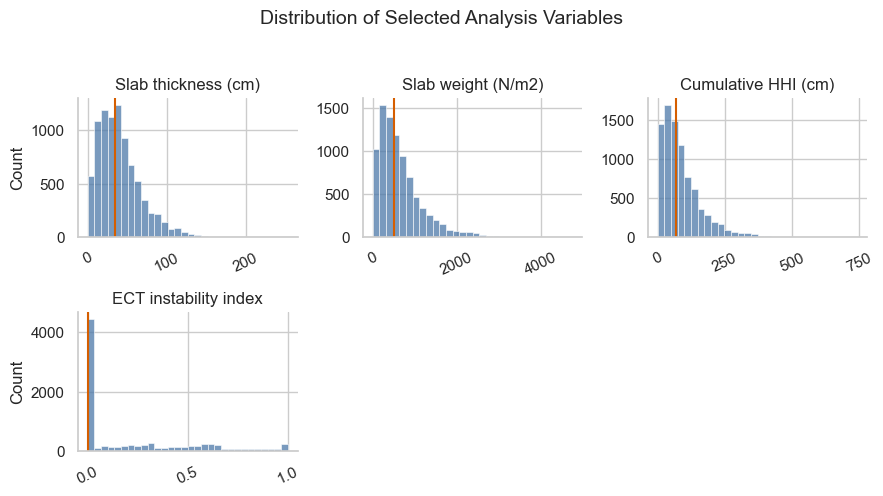

In [34]:
distribution_df = analysis_df[ANALYSIS_FEATURE_COLUMNS].rename(
    columns=FEATURE_DISPLAY_NAMES
)
distribution_long_df = distribution_df.melt(
    var_name="feature",
    value_name="value",
)

grid = sns.FacetGrid(
    distribution_long_df,
    col="feature",
    col_wrap=3,
    sharex=False,
    sharey=False,
    height=2.4,
    aspect=1.25,
)
grid.map_dataframe(
    sns.histplot,
    x="value",
    bins=30,
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.4,
)
grid.set_titles("{col_name}")
grid.set_axis_labels("", "Count")

for axis, feature in zip(grid.axes.flat, distribution_df.columns):
    median_value = distribution_df[feature].median()
    axis.axvline(median_value, color="#D55E00", linewidth=1.5)
    axis.tick_params(axis="x", labelrotation=25)

grid.figure.suptitle(
    "Distribution of Selected Analysis Variables",
    y=1.03,
    fontsize=14,
)
grid.figure.tight_layout()


## PCA

PCA reduces the scaled feature matrix to orthogonal components. The first two components are used for plotting and clustering because they explain most of the retained variance.


,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.719,0.719
1,PC2,0.250,0.969
2,PC3,0.027,0.996
3,PC4,0.004,1.000


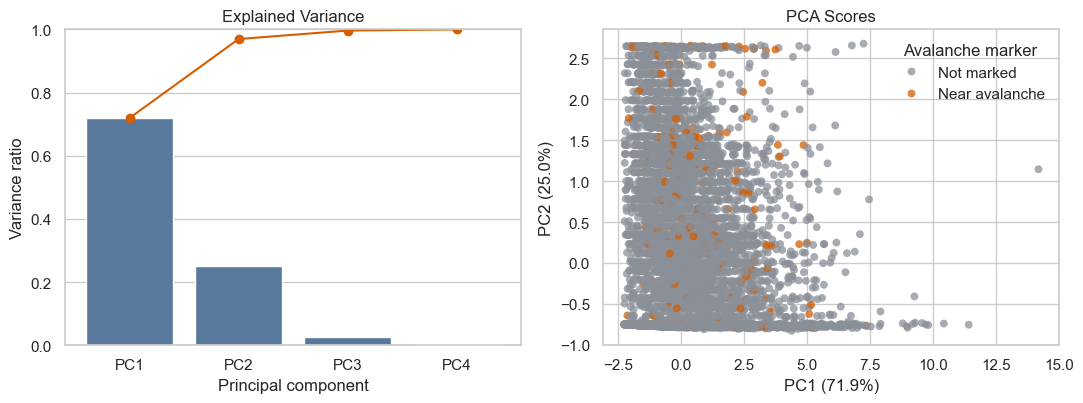

In [35]:
n_pca_components = len(ANALYSIS_FEATURE_COLUMNS)
pca_model = PCA(n_components=n_pca_components)
pca_scores = pca_model.fit_transform(pca_feature_matrix)

pca_component_columns = [
    f"PC{component_number}"
    for component_number in range(1, n_pca_components + 1)
]
pca_scores_df = pd.DataFrame(
    pca_scores,
    columns=pca_component_columns,
    index=analysis_df.index,
)

pca_results_df = pd.concat(
    [analysis_df[ANALYSIS_METADATA_COLUMNS], pca_scores_df],
    axis=1,
)
pca_results_df["near_avalanche_label"] = np.where(
    pca_results_df["near_avalanche"],
    "Near avalanche",
    "Not marked",
)

pca_loadings_df = pd.DataFrame(
    pca_model.components_.T,
    index=ANALYSIS_FEATURE_COLUMNS,
    columns=pca_component_columns,
).reset_index().rename(columns={"index": "feature"})
pca_loadings_df["display_name"] = pca_loadings_df["feature"].map(FEATURE_DISPLAY_NAMES)

pca_explained_variance_df = pd.DataFrame(
    {
        "component": pca_component_columns,
        "explained_variance_ratio": pca_model.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(
            pca_model.explained_variance_ratio_
        ),
    }
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

sns.barplot(
    data=pca_explained_variance_df,
    x="component",
    y="explained_variance_ratio",
    color="#4C78A8",
    ax=axes[0],
)
axes[0].plot(
    pca_explained_variance_df["component"],
    pca_explained_variance_df["cumulative_explained_variance"],
    color="#D55E00",
    marker="o",
    linewidth=1.5,
)
axes[0].set_title("Explained Variance")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Variance ratio")
axes[0].set_ylim(0, 1)

sns.scatterplot(
    data=pca_results_df,
    x="PC1",
    y="PC2",
    hue="near_avalanche_label",
    hue_order=["Not marked", "Near avalanche"],
    palette={"Not marked": "#8A8F98", "Near avalanche": "#D55E00"},
    alpha=0.75,
    s=32,
    edgecolor="none",
    ax=axes[1],
)
axes[1].set_title("PCA Scores")
axes[1].set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]:.1%})")
axes[1].legend(title="Avalanche marker", frameon=False)
fig.tight_layout()

pca_explained_variance_df


## K-Means Clustering

K-means is fit on PC1 and PC2 with a fixed random seed for reproducibility. The near-avalanche marker is plotted as a point style for interpretation only.


,PC1,PC2,cluster,cluster_label
0,2.460,-0.063,0,Cluster 0
1,-0.749,0.019,1,Cluster 1


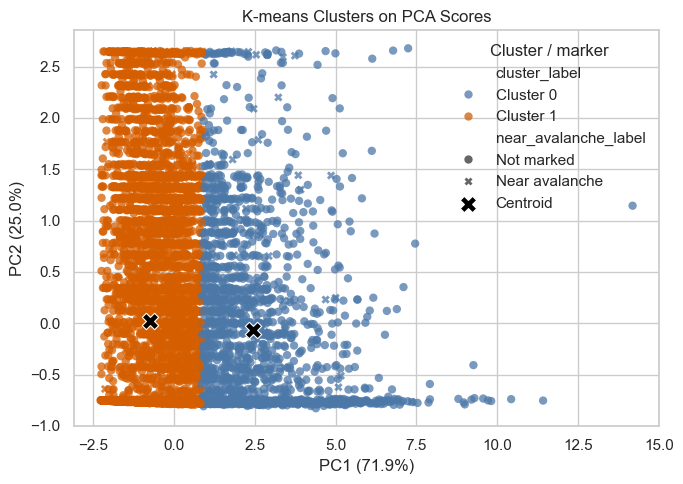

In [36]:
cluster_feature_columns = ["PC1", "PC2"]
cluster_feature_matrix = pca_results_df[cluster_feature_columns].to_numpy()

kmeans_model = KMeans(
    n_clusters=KMEANS_N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=50,
)
cluster_labels = kmeans_model.fit_predict(cluster_feature_matrix)
kmeans_silhouette_score = silhouette_score(
    cluster_feature_matrix,
    cluster_labels,
)

clustered_slabs_df = pca_results_df.copy()
clustered_slabs_df["cluster"] = cluster_labels
clustered_slabs_df["cluster_label"] = clustered_slabs_df["cluster"].map(
    lambda cluster_id: f"Cluster {cluster_id}"
)
clustered_slabs_df["near_avalanche_flag"] = clustered_slabs_df["near_avalanche"]

cluster_centers_df = pd.DataFrame(
    kmeans_model.cluster_centers_,
    columns=cluster_feature_columns,
)
cluster_centers_df["cluster"] = range(KMEANS_N_CLUSTERS)
cluster_centers_df["cluster_label"] = cluster_centers_df["cluster"].map(
    lambda cluster_id: f"Cluster {cluster_id}"
)

fig, axis = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=clustered_slabs_df,
    x="PC1",
    y="PC2",
    hue="cluster_label",
    style="near_avalanche_label",
    hue_order=[f"Cluster {cluster_id}" for cluster_id in range(KMEANS_N_CLUSTERS)],
    style_order=["Not marked", "Near avalanche"],
    palette={"Cluster 0": "#4C78A8", "Cluster 1": "#D55E00"},
    alpha=0.75,
    s=36,
    edgecolor="none",
    ax=axis,
)
sns.scatterplot(
    data=cluster_centers_df,
    x="PC1",
    y="PC2",
    marker="X",
    color="black",
    s=140,
    edgecolor="white",
    linewidth=0.8,
    ax=axis,
    label="Centroid",
)
axis.set_title("K-means Clusters on PCA Scores")
axis.set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]:.1%})")
axis.set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]:.1%})")
axis.legend(title="Cluster / marker", frameon=False, loc="best")
fig.tight_layout()

cluster_centers_df


## Results Interpretation

The final table compares cluster size, pit coverage, and how near-avalanche slabs are distributed across clusters. These summaries are descriptive checks, not supervised validation metrics.


In [37]:
total_slabs = len(clustered_slabs_df)
total_near_avalanche_slabs = int(clustered_slabs_df["near_avalanche_flag"].sum())
total_near_avalanche_pits = clustered_slabs_df.loc[
    clustered_slabs_df["near_avalanche_flag"],
    "pit_id",
].nunique()

cluster_results_df = (
    clustered_slabs_df.groupby("cluster", as_index=False)
    .agg(
        slab_count=("slab_id", "size"),
        unique_pit_count=("pit_id", "nunique"),
        near_avalanche_slab_count=("near_avalanche_flag", "sum"),
        near_avalanche_pit_count=(
            "pit_id",
            lambda pit_ids: pit_ids[
                clustered_slabs_df.loc[pit_ids.index, "near_avalanche_flag"]
            ].nunique(),
        ),
    )
)
cluster_results_df["cluster_label"] = cluster_results_df["cluster"].map(
    lambda cluster_id: f"Cluster {cluster_id}"
)
cluster_results_df["cluster_share_of_all_slabs"] = (
    cluster_results_df["slab_count"] / total_slabs
)
cluster_results_df["near_avalanche_share_within_cluster"] = (
    cluster_results_df["near_avalanche_slab_count"]
    / cluster_results_df["slab_count"]
)
cluster_results_df["proportion_of_near_avalanche_slabs_in_cluster"] = np.where(
    total_near_avalanche_slabs > 0,
    cluster_results_df["near_avalanche_slab_count"]
    / total_near_avalanche_slabs,
    np.nan,
)
cluster_results_df[
    "proportion_of_near_avalanche_pits_represented_in_cluster"
] = np.where(
    total_near_avalanche_pits > 0,
    cluster_results_df["near_avalanche_pit_count"]
    / total_near_avalanche_pits,
    np.nan,
)
cluster_results_df = cluster_results_df[
    [
        "cluster_label",
        "slab_count",
        "unique_pit_count",
        "near_avalanche_slab_count",
        "near_avalanche_pit_count",
        "cluster_share_of_all_slabs",
        "near_avalanche_share_within_cluster",
        "proportion_of_near_avalanche_slabs_in_cluster",
        "proportion_of_near_avalanche_pits_represented_in_cluster",
    ]
]

analysis_summary_df = pd.DataFrame(
    {
        "metric": [
            "PCA rows",
            "PC1 + PC2 explained variance",
            "K-means clusters",
            "K-means silhouette score",
            "Near-avalanche slabs in analysis",
            "Near-avalanche pits in analysis",
        ],
        "value": [
            f"{len(clustered_slabs_df):,}",
            f"{pca_model.explained_variance_ratio_[:2].sum():.1%}",
            KMEANS_N_CLUSTERS,
            f"{kmeans_silhouette_score:.3f}",
            f"{total_near_avalanche_slabs:,}",
            f"{total_near_avalanche_pits:,}",
        ],
    }
)

display(analysis_summary_df)
cluster_results_df


,metric,value
0,PCA rows,"8,579"
1,PC1 + PC2 explained variance,96.9%
2,K-means clusters,2
3,K-means silhouette score,0.487
4,Near-avalanche slabs in analysis,316
5,Near-avalanche pits in analysis,316


,cluster_label,slab_count,unique_pit_count,near_avalanche_slab_count,near_avalanche_pit_count,cluster_share_of_all_slabs,near_avalanche_share_within_cluster,proportion_of_near_avalanche_slabs_in_cluster,proportion_of_near_avalanche_pits_represented_in_cluster
0,Cluster 0,1998,1998,91,91,0.233,0.046,0.288,0.288
1,Cluster 1,6581,6581,225,225,0.767,0.034,0.712,0.712
